   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.9 MB/s eta 0:00:00
Device : cuda
Backbone: efficientnet-b4
GPU    : Tesla T4

Total samples found : 1467
Samples with masks  : 1467

Class distribution:
class_name
normal       729
benign       477
malignant    261
Name: count, dtype: int64



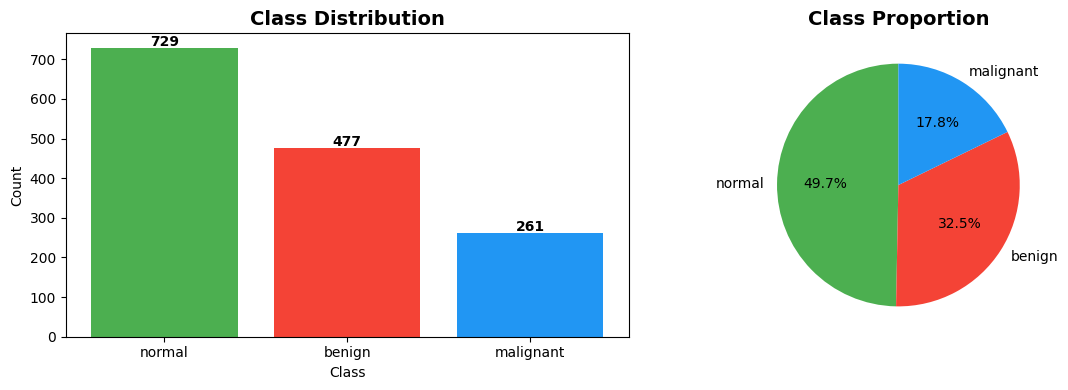

Train : 1026 samples
Val   :  220 samples
Test  :  221 samples


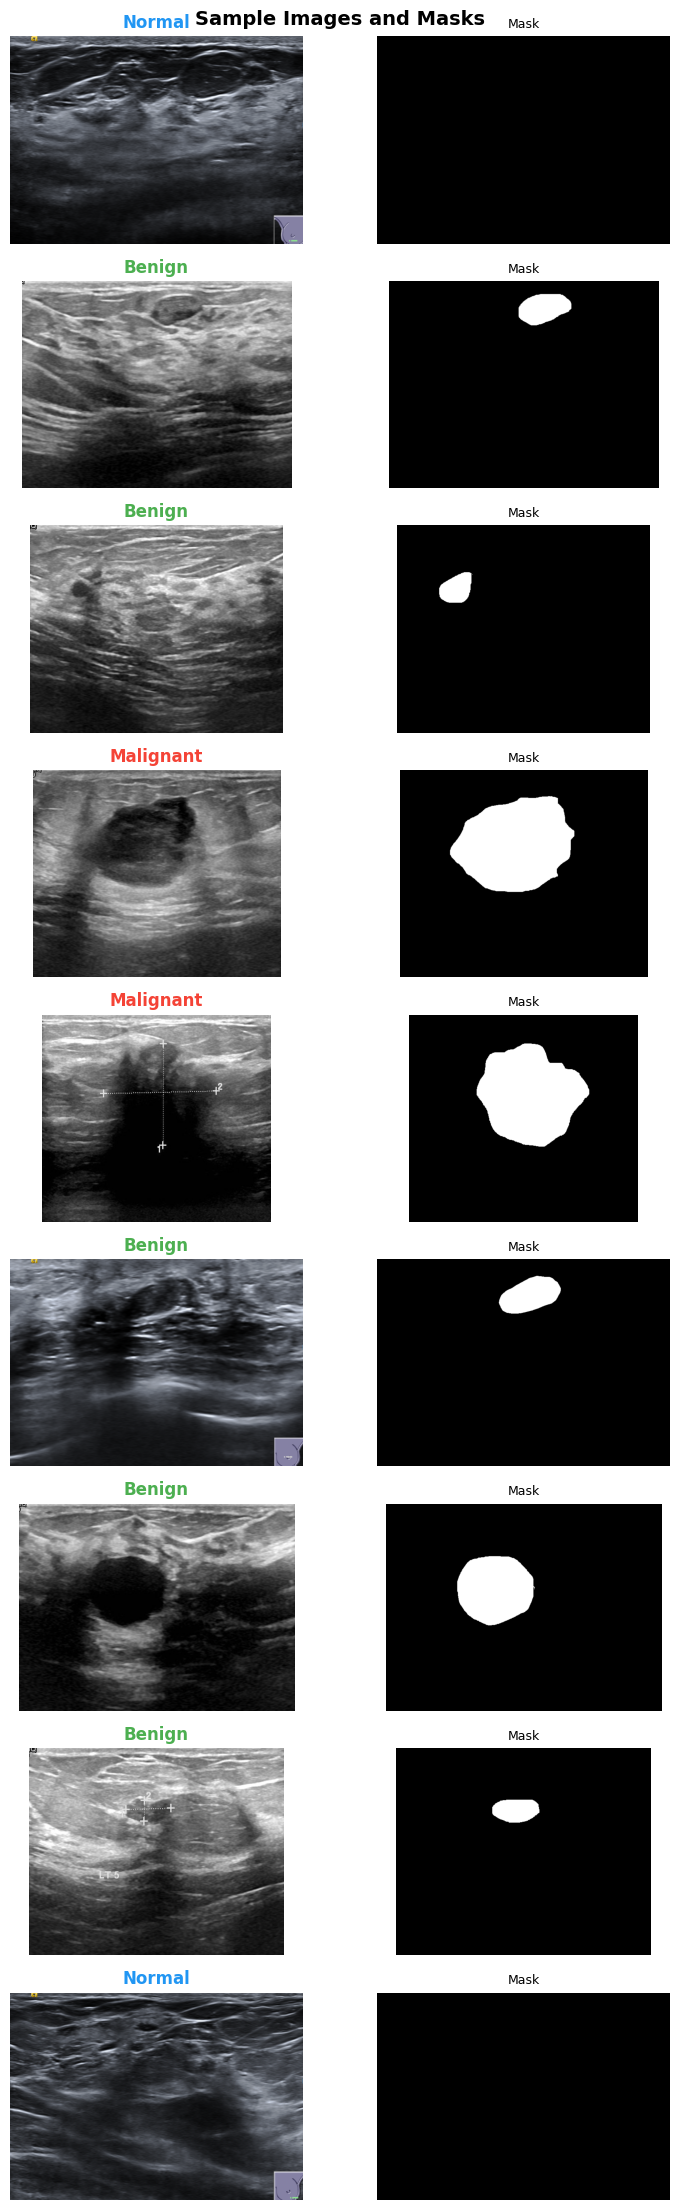

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Segmentation output shape : torch.Size([2, 1, 256, 256])
Classification output shape: torch.Size([2, 3])

Total parameters   : 20,589,212
Trainable params   : 20,589,212
Approx model size  : 78.54 MB

############################################################
# PHASE 1: TRAINING WITHOUT DATA AUGMENTATION
############################################################

 TRAINING PHASE: PHASE1_NO_AUG
 Augmentation  : DISABLED

Ep   1/80 | Time:  49.5s | Train Loss: 0.6229 | Train Acc: 0.6433 | Val Loss: 0.6239 | Val Acc: 0.6000 | Val Dice: 0.3136 | Val IoU: 0.2440 | LR: 3.00e-04
Ep   5/80 | Time:  16.9s | Train Loss: 0.2820 | Train Acc: 0.9123 | Val Loss: 0.4280 | Val Acc: 0.7773 | Val Dice: 0.5174 | Val IoU: 0.4584 | LR: 3.00e-04
Ep  10/80 | Time:  17.1s | Train Loss: 0.2044 | Train Acc: 0.9610 | Val Loss: 0.3983 | Val Acc: 0.7955 | Val Dice: 0.7794 | Val IoU: 0.7325 | LR: 3.00e-04
Ep  15/80 | Time:  17.3s | Train Loss: 0.1826 | Train Acc: 0.9571 | Val Loss: 0.4110 | Val Acc: 0.8091 | Va

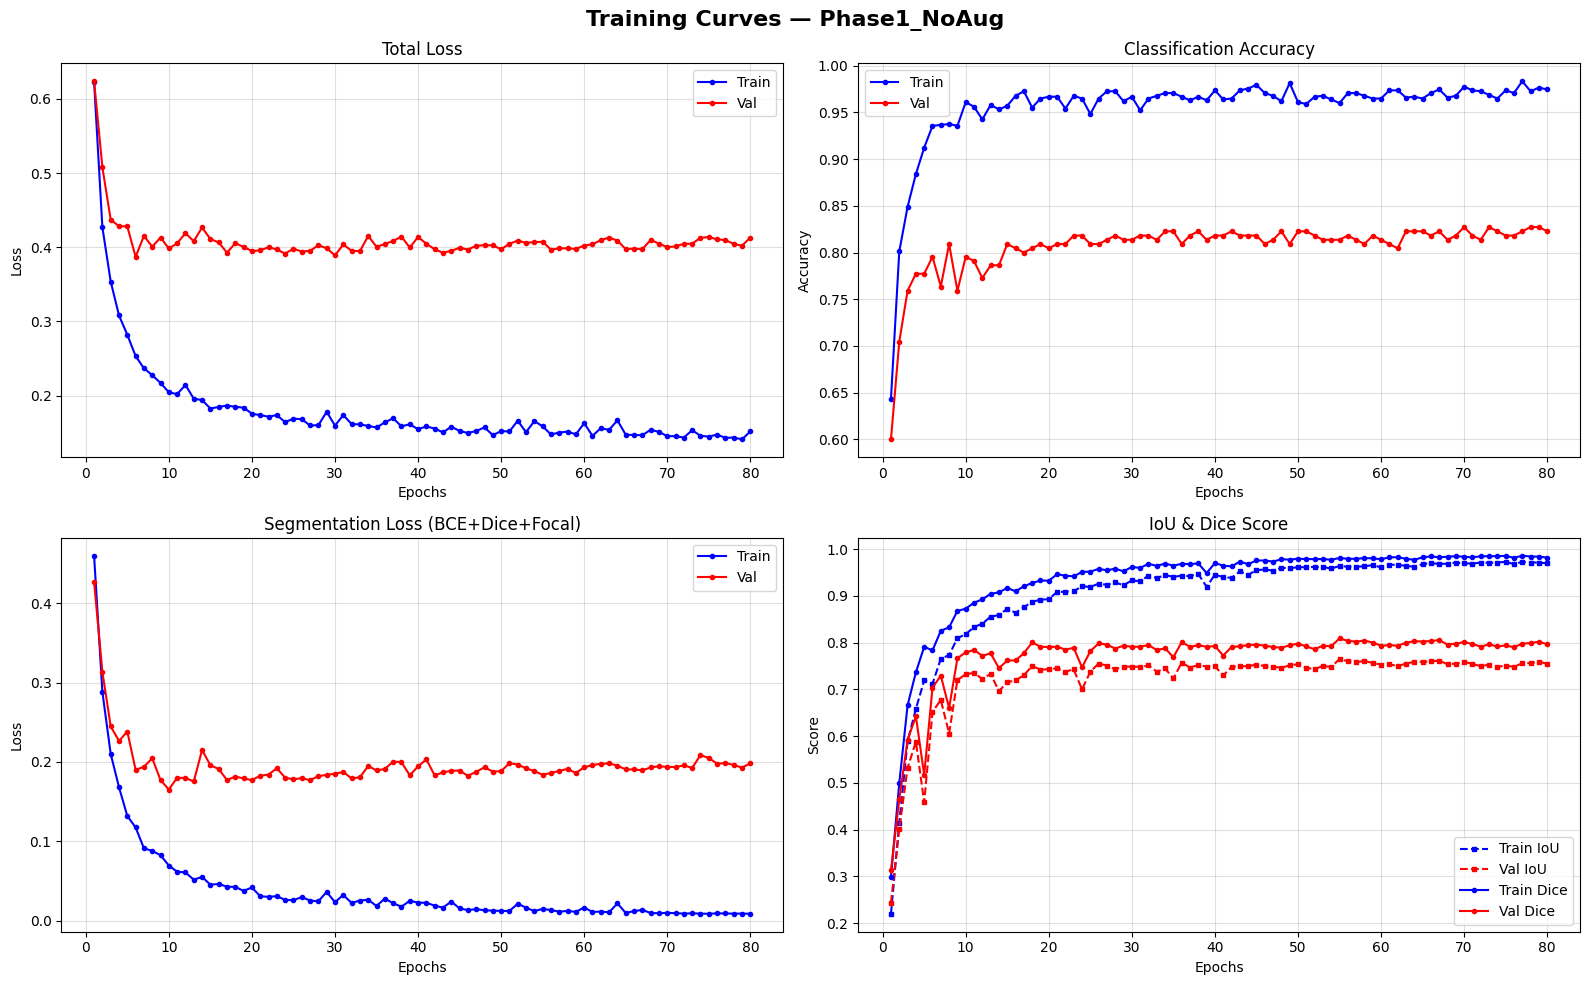

Saved: /kaggle/working/training_curves_Phase1_NoAug.png


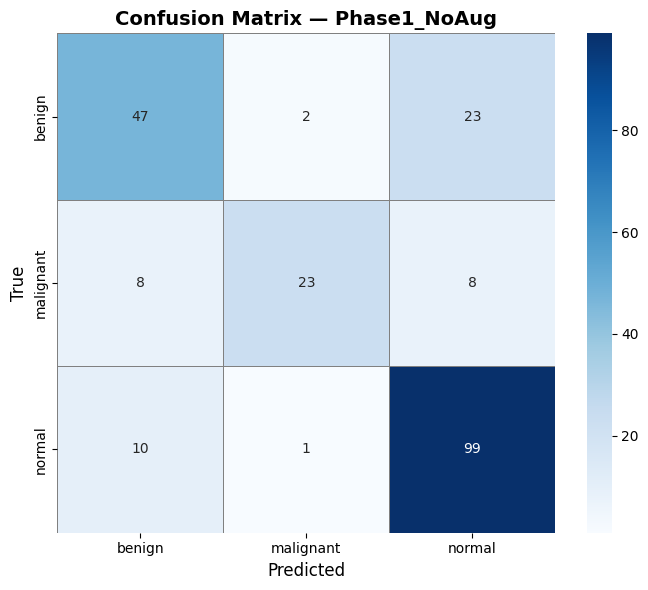

Saved: /kaggle/working/confusion_matrix_Phase1_NoAug.png


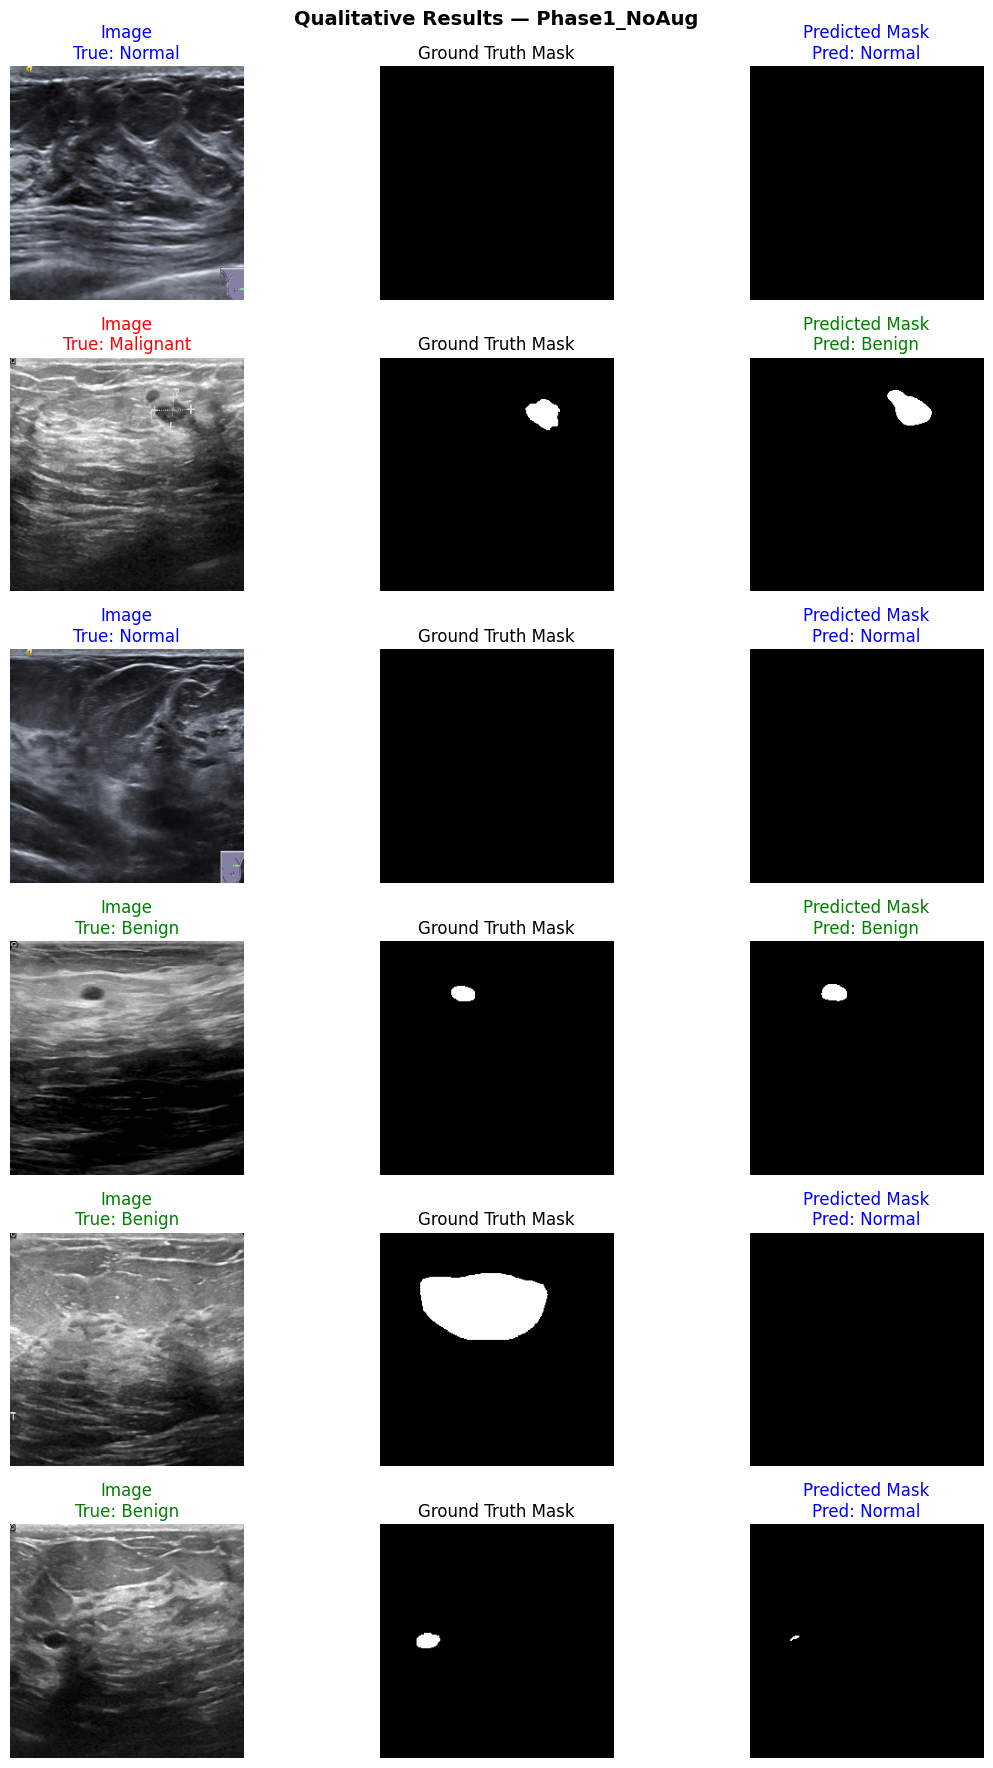


############################################################
# PHASE 2: TRAINING WITH STRONG DATA AUGMENTATION
############################################################

 TRAINING PHASE: PHASE2_AUG
 Augmentation  : ENABLED

Ep   1/80 | Time:  19.3s | Train Loss: 0.7353 | Train Acc: 0.4513 | Val Loss: 0.6670 | Val Acc: 0.5273 | Val Dice: 0.2319 | Val IoU: 0.1720 | LR: 3.00e-04
Ep   5/80 | Time:  19.1s | Train Loss: 0.5530 | Train Acc: 0.5916 | Val Loss: 0.4395 | Val Acc: 0.7727 | Val Dice: 0.6091 | Val IoU: 0.5580 | LR: 3.00e-04
Ep  10/80 | Time:  19.0s | Train Loss: 0.4932 | Train Acc: 0.6413 | Val Loss: 0.3842 | Val Acc: 0.7955 | Val Dice: 0.6905 | Val IoU: 0.6347 | LR: 3.00e-04
Ep  15/80 | Time:  18.8s | Train Loss: 0.4677 | Train Acc: 0.6930 | Val Loss: 0.3793 | Val Acc: 0.7955 | Val Dice: 0.6927 | Val IoU: 0.6350 | LR: 3.00e-04
Ep  20/80 | Time:  19.1s | Train Loss: 0.4450 | Train Acc: 0.7203 | Val Loss: 0.3744 | Val Acc: 0.7864 | Val Dice: 0.6886 | Val IoU: 0.6259 | LR: 3.00e-

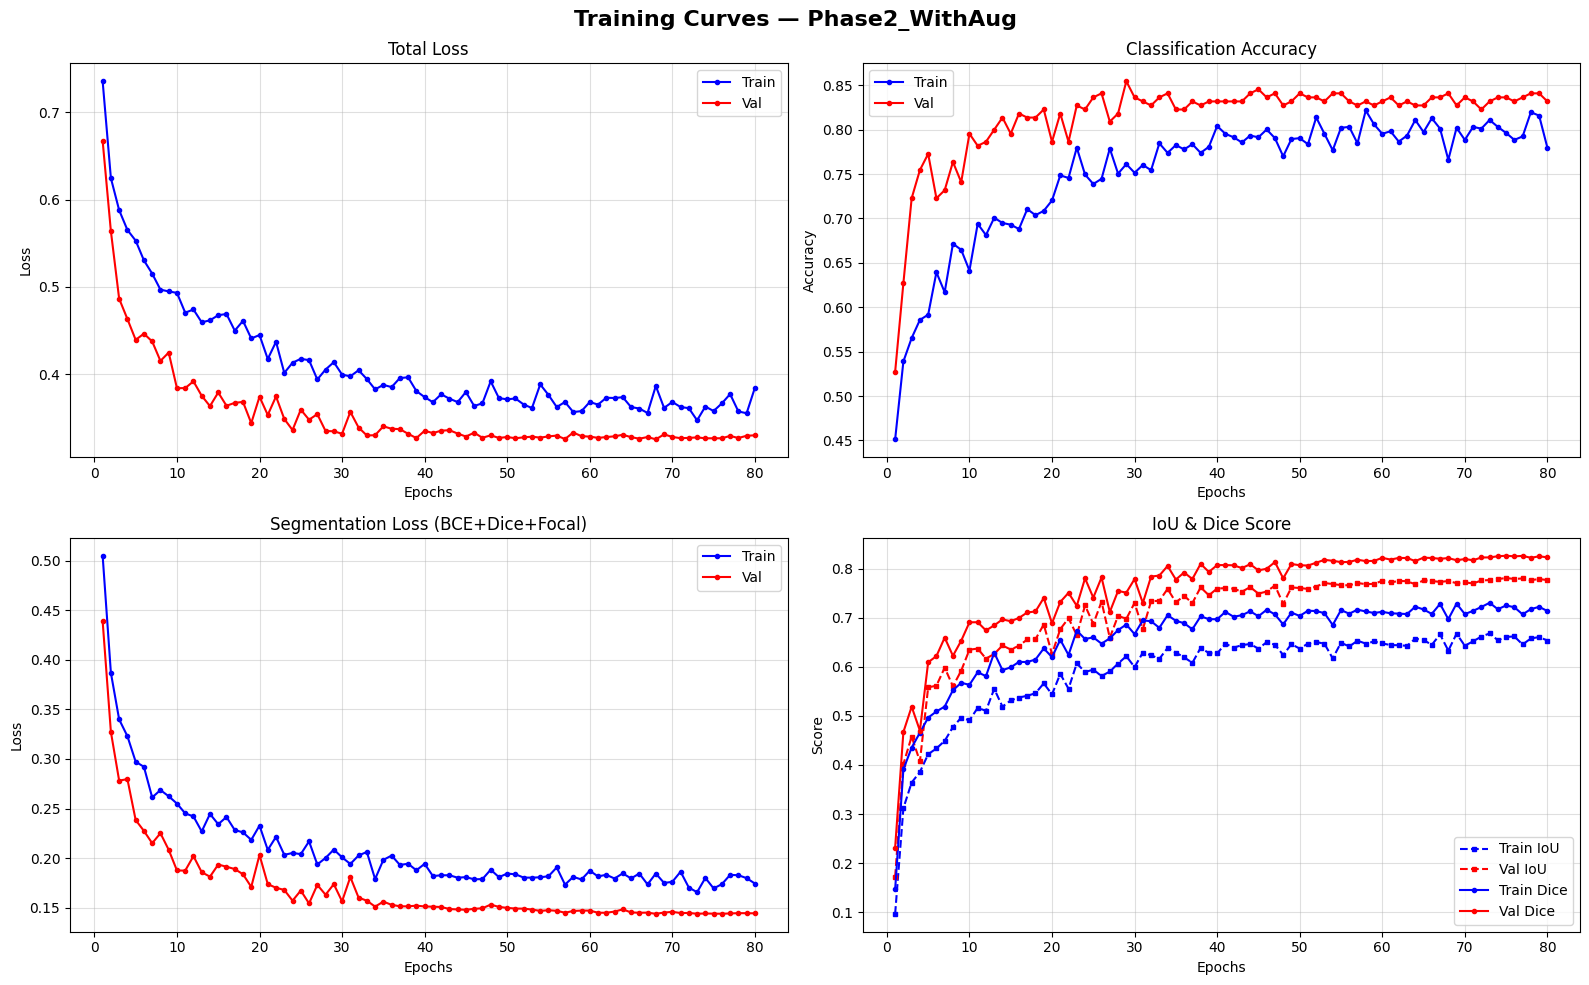

Saved: /kaggle/working/training_curves_Phase2_WithAug.png


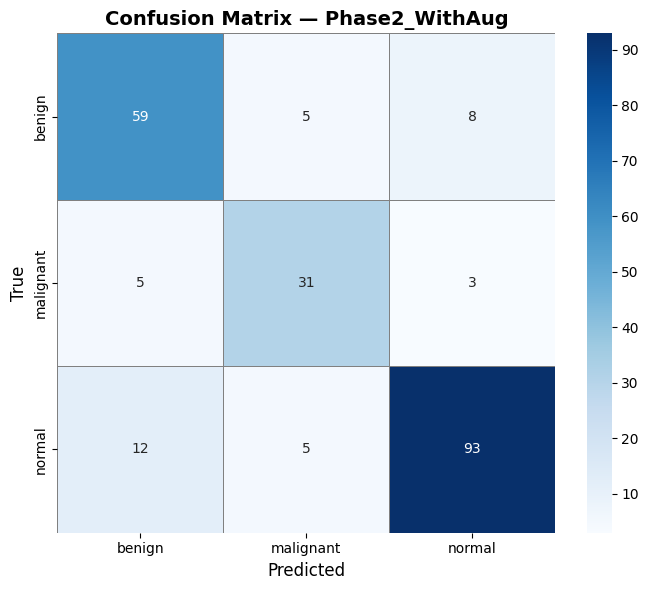

Saved: /kaggle/working/confusion_matrix_Phase2_WithAug.png


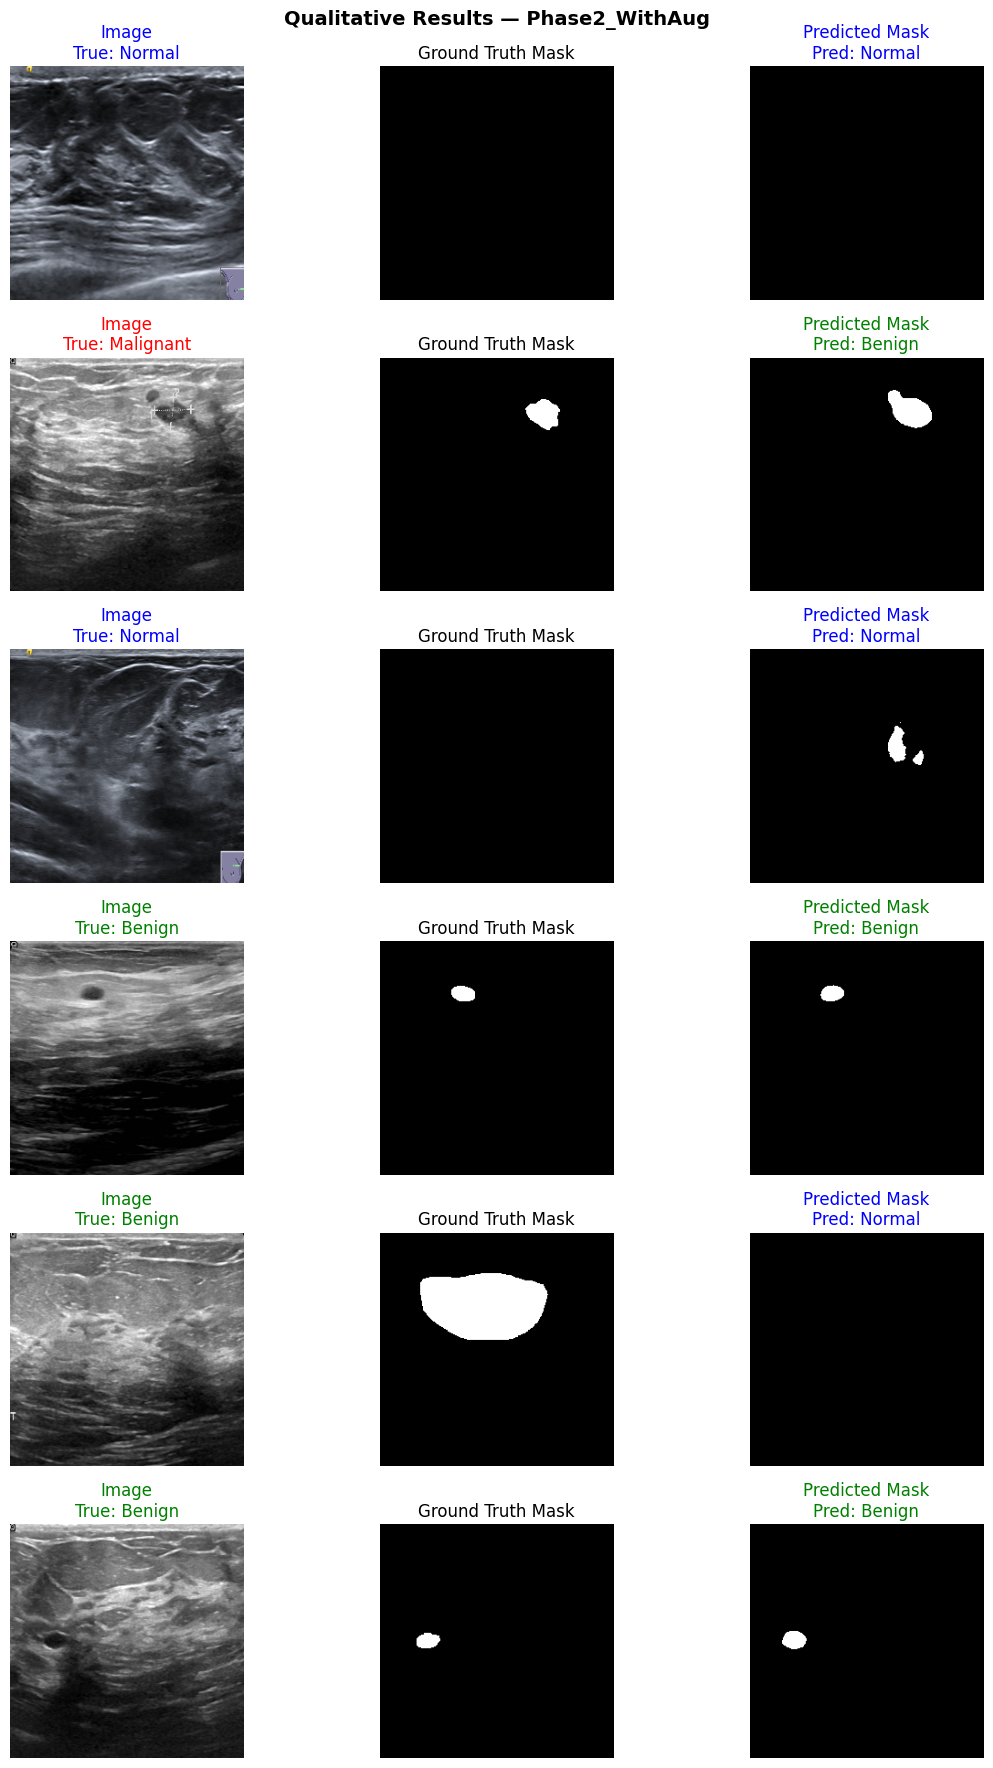


 FULL COMPARISON TABLE: Phase 1 (No Aug) vs Phase 2 (With Aug)
Phase            No Augmentation With Augmentation
Cls Accuracy              0.7647            0.8281
Cls Precision             0.7707            0.8314
Cls Recall                0.7647            0.8281
Cls F1                    0.7591            0.8291
Seg IoU                   0.7565            0.7311
Seg Dice                  0.8001            0.7817
Seg Px-Acc                0.9783            0.9756
Seg Precision             0.9060            0.8648
Seg Recall                0.8138            0.8341
# Params (M)               20.59             20.59
Size (MB)                  78.54             78.54
Train Time (min)           23.47             25.64
Avg Ep (s)                 17.60             19.23


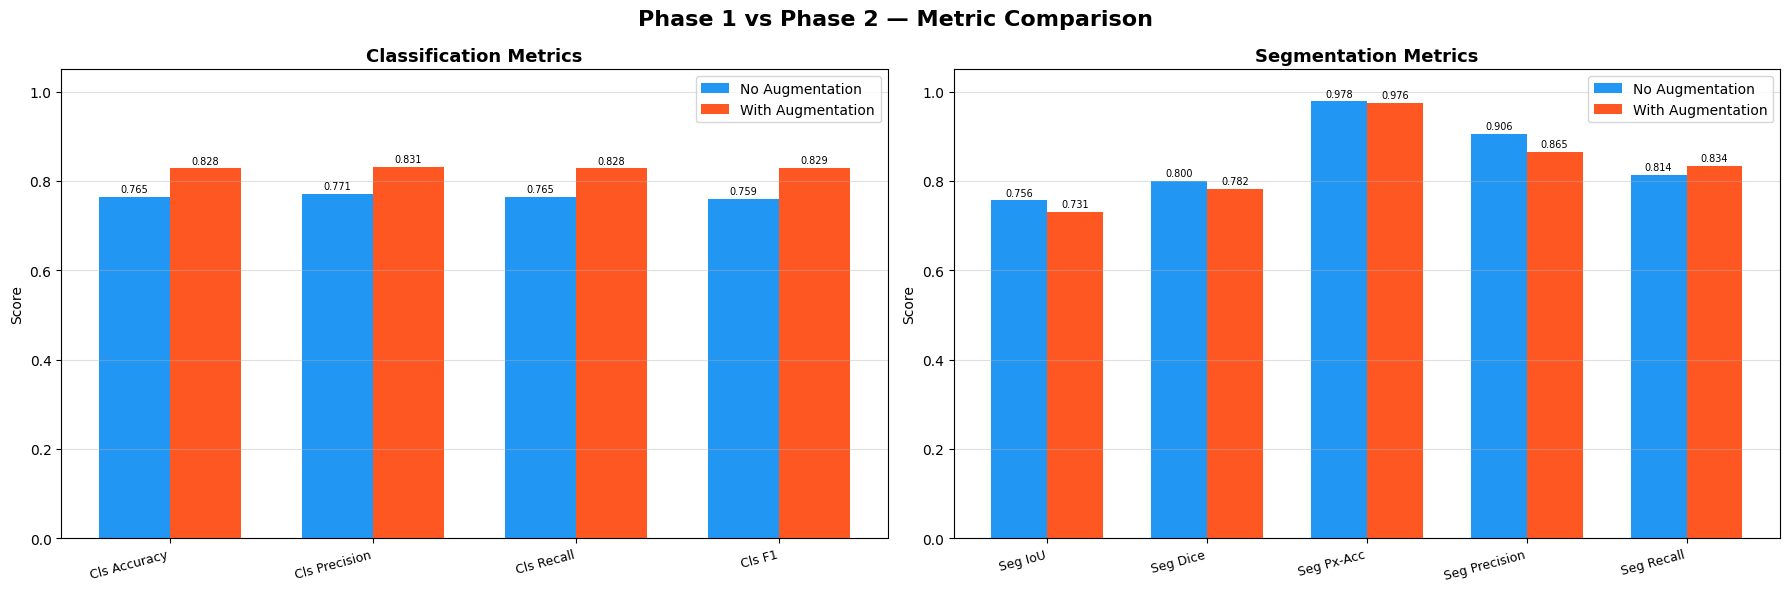

Saved: /kaggle/working/metric_comparison_bars.png


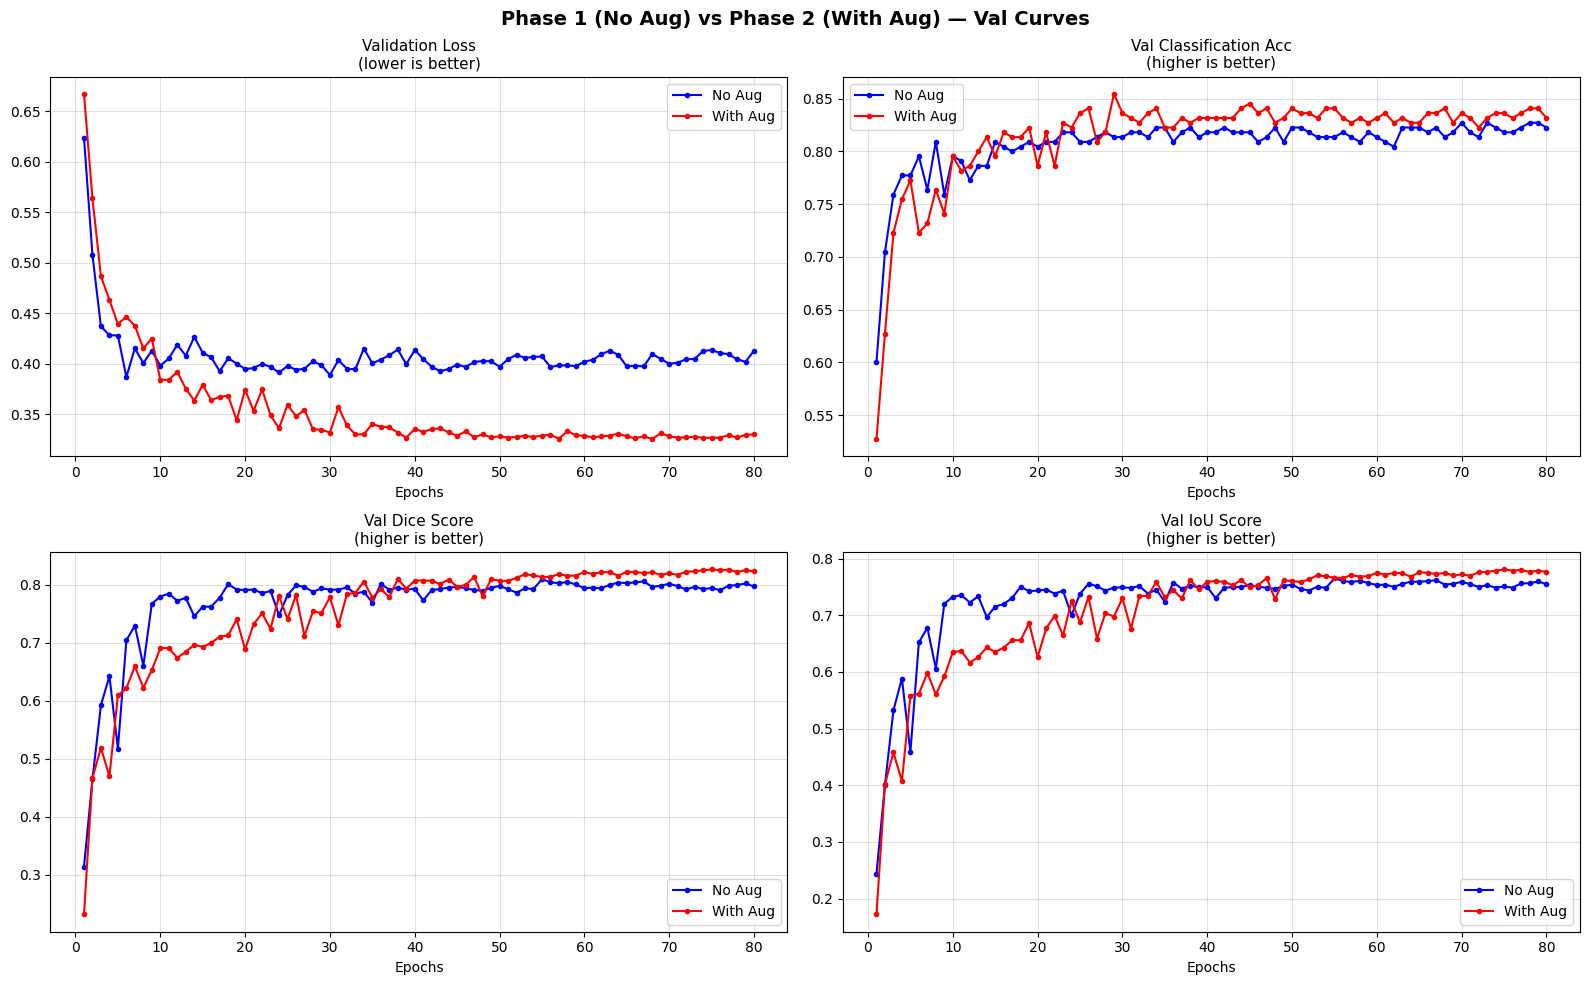

Saved: /kaggle/working/overlay_curves.png

  FINAL SUMMARY

  Backbone      : efficientnet-b4
  Image Size    : 256×256
  Epochs        : 80
  Batch Size    : 16
  Optimizer     : AdamW (Cosine Annealing WR)
  Loss          : BCE+Dice+Focal (seg) + CrossEntropy (cls)

  [Phase 1 — No Augmentation]
    Cls Accuracy : 0.7647
    Cls F1       : 0.7591
    Seg Dice     : 0.8001
    Seg IoU      : 0.7565

  [Phase 2 — With Strong Augmentation]
    Cls Accuracy : 0.8281
    Cls F1       : 0.8291
    Seg Dice     : 0.7817
    Seg IoU      : 0.7311

  Files saved to /kaggle/working/

  Saved output files:
    Sample_Images_and_Masks.png
    class_distribution.png
    comparison_table.csv
    confusion_matrix_Phase1_NoAug.png
    confusion_matrix_Phase2_WithAug.png
    metric_comparison_bars.png
    overlay_curves.png
    qualitative_Phase1_NoAug.png
    qualitative_Phase2_WithAug.png
    training_curves_Phase1_NoAug.png
    training_curves_Phase2_WithAug.png


In [1]:
# =============================================================================
# BREAST LESION SEGMENTATION & CLASSIFICATION PIPELINE
# Model: U-Net with EfficientNet-B4/B5 Backbone (Multi-Task Learning)
# Tasks: Classification (3-class) + Segmentation (binary mask)
# Dataset: Combined BUSI + BUS-UCLM Dataset
# Platform: Kaggle
# =============================================================================

# ============================================================
# CELL 1 — Install Required Libraries
# ============================================================
import subprocess
subprocess.run(["pip", "install", "-q",
                "segmentation-models-pytorch",
                "albumentations",
                "timm",
                "torchmetrics",
                "mlxtend"], check=False)

# ============================================================
# CELL 2 — Import All Libraries
# ============================================================

import os
import glob
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import (CosineAnnealingLR,
                                       CosineAnnealingWarmRestarts,
                                       OneCycleLR,
                                       ReduceLROnPlateau)
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

from torchmetrics import (Accuracy, Precision, Recall, F1Score,
                           ConfusionMatrix, JaccardIndex)

from torchmetrics.segmentation import GeneralizedDiceScore

warnings.filterwarnings("ignore")

# ============================================================
# CELL 3 — Configuration & Hyperparameters
# ============================================================

class CFG:
    DATA_ROOT   = "/kaggle/input/datasets/arittrosahadhrubo/breast-lesion-segmentation-dataset1/combined_dataset"
    CLASSES     = ["benign", "malignant", "normal"]
    NUM_CLASSES = 3

    IMG_SIZE    = 256
    CHANNELS    = 3

    SEED        = 42
    EPOCHS      = 80           # increased; EarlyStopping controls actual stopping
    BATCH_SIZE  = 16
    NUM_WORKERS = 2
    VAL_SPLIT   = 0.15
    TEST_SPLIT  = 0.15
    PIN_MEMORY  = True

    LR          = 3e-4
    WEIGHT_DECAY= 2e-4         # slightly increased for better regularisation
    ENC_LR_MULT = 0.1
    GRAD_CLIP   = 1.0

    # ── Early Stopping ──────────────────────────────────────────────────────
    EARLY_STOP_PATIENCE = 12   # stop if no improvement for 12 epochs
    # ── ReduceLROnPlateau (adaptive LR) ─────────────────────────────────────
    LR_PATIENCE = 5            # reduce LR after 5 epochs of no improvement
    LR_FACTOR   = 0.5          # multiply LR by 0.5 on plateau
    MIN_LR      = 1e-6         # floor for the LR

    CLS_WEIGHT  = 0.4
    SEG_WEIGHT  = 0.6

    BACKBONE        = "efficientnet-b4"
    ENCODER_WEIGHTS = "imagenet"
    DROPOUT         = 0.3

    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
    SAVE_DIR    = "/kaggle/working/checkpoints"
    LOG_INTERVAL= 5

os.makedirs(CFG.SAVE_DIR, exist_ok=True)

def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything()
print(f"Device : {CFG.DEVICE}")
print(f"Backbone: {CFG.BACKBONE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ============================================================
# CELL 4 — Dataset Discovery & Exploration
# ============================================================

def collect_samples(data_root: str) -> pd.DataFrame:
    records   = []
    label_map = {cls: idx for idx, cls in enumerate(CFG.CLASSES)}

    for cls in CFG.CLASSES:
        img_dir  = Path(data_root) / cls / "images"
        mask_dir = Path(data_root) / cls / "masks"

        if not img_dir.exists():
            print(f"[WARNING] Directory not found: {img_dir}")
            continue

        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
            for img_path in sorted(img_dir.glob(ext)):
                stem      = img_path.stem
                mask_path = None
                for m_ext in (".png", ".jpg", ".jpeg", ".bmp"):
                    candidate = mask_dir / (stem + m_ext)
                    if candidate.exists():
                        mask_path = candidate; break
                    candidate2 = mask_dir / (stem + "_mask" + m_ext)
                    if candidate2.exists():
                        mask_path = candidate2; break

                records.append({
                    "image_path": str(img_path),
                    "mask_path" : str(mask_path) if mask_path else None,
                    "label"     : label_map[cls],
                    "class_name": cls
                })

    df = pd.DataFrame(records)
    print(f"\n{'='*50}")
    print(f"Total samples found : {len(df)}")
    print(f"Samples with masks  : {df['mask_path'].notna().sum()}")
    print(f"\nClass distribution:")
    print(df["class_name"].value_counts())
    print(f"{'='*50}\n")
    return df

df = collect_samples(CFG.DATA_ROOT)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df["class_name"].value_counts()
colors = ["#4CAF50", "#F44336", "#2196F3"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 5, str(cnt), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=counts.index,
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Class Proportion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_df, test_df = train_test_split(
    df, test_size=CFG.TEST_SPLIT,
    stratify=df["label"], random_state=CFG.SEED)

train_df, val_df = train_test_split(
    train_df,
    test_size=CFG.VAL_SPLIT / (1 - CFG.TEST_SPLIT),
    stratify=train_df["label"], random_state=CFG.SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df  .reset_index(drop=True)
test_df  = test_df .reset_index(drop=True)

print(f"Train : {len(train_df):4d} samples")
print(f"Val   : {len(val_df):4d} samples")
print(f"Test  : {len(test_df):4d} samples")

# ============================================================
# CELL 5 — Augmentation Pipelines
# ============================================================
# FIX: Pass is_check_shapes=False to every A.Compose so that
#      mismatched image/mask sizes don't raise before A.Resize
#      gets a chance to normalise them.

def get_transforms(mode: str, augment: bool = False) -> A.Compose:
    base = [
        A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2()
    ]

    if mode != "train" or not augment:
        return A.Compose(
            base,
            additional_targets={"mask": "mask"},
            is_check_shapes=False          # ← FIX
        )

    aug = [
        A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),

        # Geometry
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.4),
        A.ShiftScaleRotate(
            shift_limit=0.1, scale_limit=0.2,
            rotate_limit=30, border_mode=0, p=0.6),
        A.ElasticTransform(alpha=120, sigma=6, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.OpticalDistortion(distort_limit=0.2, p=0.2),
        A.Perspective(scale=(0.05, 0.1), p=0.3),

        # Pixel / Colour
        A.RandomBrightnessContrast(brightness_limit=0.3,
                                    contrast_limit=0.3, p=0.6),
        A.HueSaturationValue(hue_shift_limit=15,
                              sat_shift_limit=30,
                              val_shift_limit=20, p=0.4),
        A.CLAHE(clip_limit=4.0, p=0.4),
        A.GaussNoise(var_limit=(10, 50), p=0.3),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.Sharpen(alpha=(0.2, 0.5), p=0.2),
        A.CoarseDropout(max_holes=8, max_height=20,
                         max_width=20, fill_value=0, p=0.3),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std =(0.229, 0.224, 0.225)),
        ToTensorV2()
    ]

    return A.Compose(
        aug,
        additional_targets={"mask": "mask"},
        is_check_shapes=False              # ← FIX
    )


# ============================================================
# CELL 6 — Custom Dataset Class
# ============================================================

class BreastLesionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame,
                 transform: A.Compose = None):
        self.df        = dataframe.copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row["image_path"]).convert("RGB"),
            dtype=np.uint8)

        if row["mask_path"] and os.path.exists(row["mask_path"]):
            mask = np.array(
                Image.open(row["mask_path"]).convert("L"),
                dtype=np.uint8)
            mask = (mask > 127).astype(np.uint8)
        else:
            mask = np.zeros(
                (image.shape[0], image.shape[1]), dtype=np.uint8)

        # ── FIX: force mask to match image spatial dims BEFORE
        #         passing to Albumentations, as a safety net.
        if mask.shape != image.shape[:2]:
            mask = np.array(
                Image.fromarray(mask).resize(
                    (image.shape[1], image.shape[0]),   # (W, H)
                    Image.NEAREST),
                dtype=np.uint8)

        label = int(row["label"])

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image     = augmented["image"]
            mask      = augmented["mask"]

        mask  = mask.float().unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)

        return image, mask, label


def build_loaders(augment: bool):
    train_tf = get_transforms("train", augment=augment)
    val_tf   = get_transforms("val",   augment=False)
    test_tf  = get_transforms("test",  augment=False)

    train_ds = BreastLesionDataset(train_df, transform=train_tf)
    val_ds   = BreastLesionDataset(val_df,   transform=val_tf)
    test_ds  = BreastLesionDataset(test_df,  transform=test_tf)

    class_counts   = train_df["label"].value_counts().sort_index().values
    sample_weights = [1.0 / class_counts[lbl]
                      for lbl in train_df["label"]]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_df),
        replacement=True)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                              sampler=sampler,
                              num_workers=CFG.NUM_WORKERS,
                              pin_memory=CFG.PIN_MEMORY)
    val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                              shuffle=False,
                              num_workers=CFG.NUM_WORKERS,
                              pin_memory=CFG.PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                              shuffle=False,
                              num_workers=CFG.NUM_WORKERS,
                              pin_memory=CFG.PIN_MEMORY)
    return train_loader, val_loader, test_loader


# ============================================================
# CELL 7 — Visualise Sample Images
# ============================================================

def visualise_samples(df: pd.DataFrame, n: int = 9,
                      title: str = "Sample Images"):
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 2.5))
    indices = random.sample(range(len(df)), min(n, len(df)))
    colors  = {0: "#4CAF50", 1: "#F44336", 2: "#2196F3"}
    cname   = {0: "Benign", 1: "Malignant", 2: "Normal"}

    for row_i, idx in enumerate(indices):
        rec   = df.iloc[idx]
        img   = Image.open(rec["image_path"]).convert("RGB")
        label = int(rec["label"])

        axes[row_i, 0].imshow(img)
        axes[row_i, 0].set_title(
            f"{cname[label]}", color=colors[label], fontweight="bold")
        axes[row_i, 0].axis("off")

        if rec["mask_path"] and os.path.exists(str(rec["mask_path"])):
            mask = Image.open(rec["mask_path"]).convert("L")
            axes[row_i, 1].imshow(mask, cmap="gray")
        else:
            axes[row_i, 1].imshow(
                np.zeros((CFG.IMG_SIZE, CFG.IMG_SIZE)), cmap="gray")
        axes[row_i, 1].set_title("Mask", fontsize=9)
        axes[row_i, 1].axis("off")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{title.replace(' ','_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

visualise_samples(df, n=9, title="Sample Images and Masks")

# ============================================================
# CELL 8 — Multi-Task U-Net Model Architecture
# ============================================================

class ClassificationHead(nn.Module):
    def __init__(self, in_channels: int,
                 num_classes: int = 3,
                 dropout: float   = 0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, features):
        x = features[-1]
        x = self.pool(x)
        return self.head(x)


class MultiTaskUNet(nn.Module):
    def __init__(self,
                 encoder_name   : str   = CFG.BACKBONE,
                 encoder_weights: str   = CFG.ENCODER_WEIGHTS,
                 num_classes    : int   = CFG.NUM_CLASSES,
                 dropout        : float = CFG.DROPOUT):
        super().__init__()

        self.unet = smp.Unet(
            encoder_name    = encoder_name,
            encoder_weights = encoder_weights,
            in_channels     = CFG.CHANNELS,
            classes         = 1,
            activation      = None,
            decoder_use_batchnorm = True,
        )

        enc_out_channels = self.unet.encoder.out_channels[-1]
        self.cls_head = ClassificationHead(
            in_channels = enc_out_channels,
            num_classes = num_classes,
            dropout     = dropout)

    def forward(self, x):
        features = self.unet.encoder(x)

        try:
            seg_logits = self.unet.decoder(features)
        except TypeError:
            seg_logits = self.unet.decoder(*features)

        seg_logits = self.unet.segmentation_head(seg_logits)
        cls_logits = self.cls_head(features)
        return seg_logits, cls_logits


# Sanity check
model  = MultiTaskUNet()
dummy  = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
seg_o, cls_o = model(dummy)
print(f"Segmentation output shape : {seg_o.shape}")
print(f"Classification output shape: {cls_o.shape}")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
print(f"\nTotal parameters   : {total_params:,}")
print(f"Trainable params   : {trainable_params:,}")
print(f"Approx model size  : {total_params * 4 / (1024**2):.2f} MB")
del model

# ============================================================
# CELL 9 — Loss Functions
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits)
        flat_p = probs.view(-1)
        flat_t = targets.view(-1)
        inter  = (flat_p * flat_t).sum()
        return 1 - (2 * inter + self.smooth) / \
                   (flat_p.sum() + flat_t.sum() + self.smooth)


class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.8, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
                  logits, targets, reduction="none")
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


class SegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce   = nn.BCEWithLogitsLoss()
        self.dice  = DiceLoss()
        self.focal = FocalLoss()

    def forward(self, logits, targets):
        return (0.4 * self.bce(logits, targets) +
                0.4 * self.dice(logits, targets) +
                0.2 * self.focal(logits, targets))


class MultiTaskLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.seg_loss = SegmentationLoss()
        self.cls_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

    def forward(self, seg_logits, cls_logits, masks, labels):
        l_seg = self.seg_loss(seg_logits, masks)
        l_cls = self.cls_loss(cls_logits, labels)
        total = CFG.SEG_WEIGHT * l_seg + CFG.CLS_WEIGHT * l_cls
        return total, l_seg, l_cls


# ============================================================
# CELL 10 — Metric Helper Functions
# ============================================================

def compute_iou(pred_mask, true_mask, threshold=0.5, eps=1e-6):
    pred_bin = (pred_mask > threshold).float()
    inter    = (pred_bin * true_mask).sum()
    union    = (pred_bin + true_mask).clamp(0, 1).sum()
    return ((inter + eps) / (union + eps)).item()

def compute_dice(pred_mask, true_mask, threshold=0.5, eps=1e-6):
    pred_bin = (pred_mask > threshold).float()
    inter    = (pred_bin * true_mask).sum()
    return ((2 * inter + eps) /
            (pred_bin.sum() + true_mask.sum() + eps)).item()

def compute_pixel_accuracy(pred_mask, true_mask, threshold=0.5):
    pred_bin = (pred_mask > threshold).float()
    correct  = (pred_bin == true_mask).float().sum()
    return (correct / pred_mask.numel()).item()

def compute_seg_precision(pred_mask, true_mask, threshold=0.5, eps=1e-6):
    pred_bin = (pred_mask > threshold).float()
    tp = (pred_bin * true_mask).sum()
    fp = (pred_bin * (1 - true_mask)).sum()
    return ((tp + eps) / (tp + fp + eps)).item()

def compute_seg_recall(pred_mask, true_mask, threshold=0.5, eps=1e-6):
    pred_bin = (pred_mask > threshold).float()
    tp = (pred_bin * true_mask).sum()
    fn = ((1 - pred_bin) * true_mask).sum()
    return ((tp + eps) / (tp + fn + eps)).item()


# ============================================================
# CELL 11 — Training & Validation Loop
# ============================================================

def build_optimizer(model: nn.Module) -> optim.Optimizer:
    encoder_ids    = set(id(p)
                         for p in model.unet.encoder.parameters())
    encoder_params = [p for p in model.parameters()
                      if id(p) in encoder_ids]
    other_params   = [p for p in model.parameters()
                      if id(p) not in encoder_ids]

    return optim.AdamW([
        {"params": encoder_params,
         "lr"    : CFG.LR * CFG.ENC_LR_MULT,
         "weight_decay": CFG.WEIGHT_DECAY},
        {"params": other_params,
         "lr"    : CFG.LR,
         "weight_decay": CFG.WEIGHT_DECAY},
    ])


def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, scheduler, device):
    model.train()
    total_loss = seg_loss_sum = cls_loss_sum = 0.0
    all_cls_preds, all_cls_labels = [], []
    all_iou, all_dice = [], []

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks .to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            seg_logits, cls_logits = model(images)
            loss, l_seg, l_cls = criterion(
                seg_logits, cls_logits, masks, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss   += loss.item()
        seg_loss_sum += l_seg.item()
        cls_loss_sum += l_cls.item()

        preds = cls_logits.argmax(dim=1).cpu().numpy()
        all_cls_preds.extend(preds)
        all_cls_labels.extend(labels.cpu().numpy())

        seg_probs = torch.sigmoid(seg_logits).detach()
        all_iou .extend([compute_iou (seg_probs[i], masks[i])
                          for i in range(len(images))])
        all_dice.extend([compute_dice(seg_probs[i], masks[i])
                          for i in range(len(images))])

    # NOTE: scheduler.step() removed from here.
    # ReduceLROnPlateau requires the validation metric, so it is
    # stepped in train_pipeline() after validate() returns.

    n        = len(loader)
    cls_acc  = accuracy_score(all_cls_labels, all_cls_preds)
    return {
        "loss"    : total_loss   / n,
        "seg_loss": seg_loss_sum / n,
        "cls_loss": cls_loss_sum / n,
        "cls_acc" : cls_acc,
        "iou"     : np.mean(all_iou),
        "dice"    : np.mean(all_dice),
    }


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = seg_loss_sum = cls_loss_sum = 0.0
    all_cls_preds, all_cls_labels = [], []
    all_iou, all_dice = [], []

    for images, masks, labels in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks .to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            seg_logits, cls_logits = model(images)
            loss, l_seg, l_cls = criterion(
                seg_logits, cls_logits, masks, labels)

        total_loss   += loss.item()
        seg_loss_sum += l_seg.item()
        cls_loss_sum += l_cls.item()

        preds = cls_logits.argmax(dim=1).cpu().numpy()
        all_cls_preds.extend(preds)
        all_cls_labels.extend(labels.cpu().numpy())

        seg_probs = torch.sigmoid(seg_logits)
        all_iou .extend([compute_iou (seg_probs[i], masks[i])
                          for i in range(len(images))])
        all_dice.extend([compute_dice(seg_probs[i], masks[i])
                          for i in range(len(images))])

    n       = len(loader)
    cls_acc = accuracy_score(all_cls_labels, all_cls_preds)
    return {
        "loss"    : total_loss   / n,
        "seg_loss": seg_loss_sum / n,
        "cls_loss": cls_loss_sum / n,
        "cls_acc" : cls_acc,
        "iou"     : np.mean(all_iou),
        "dice"    : np.mean(all_dice),
    }, all_cls_labels, all_cls_preds


# ============================================================
# CELL 11b — Early Stopping Helper
# ============================================================

class EarlyStopping:
    """
    Stops training when the monitored combined score
    (0.5 * val_dice + 0.5 * val_cls_acc) does not improve
    for `patience` consecutive epochs.
    Saves the best model weights automatically.
    """
    def __init__(self, patience: int = CFG.EARLY_STOP_PATIENCE,
                 min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score: float) -> bool:
        """Returns True if training should stop."""
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0
        return self.stop


# ============================================================
# CELL 12 — Full Training Pipeline (single phase)
# ============================================================

def train_pipeline(phase: str, augment: bool):
    print(f"\n{'='*60}")
    print(f" TRAINING PHASE: {phase.upper()}")
    print(f" Augmentation  : {'ENABLED' if augment else 'DISABLED'}")
    print(f"{'='*60}\n")

    seed_everything()
    train_loader, val_loader, test_loader = build_loaders(augment)

    model     = MultiTaskUNet().to(CFG.DEVICE)
    criterion = MultiTaskLoss()
    optimizer = build_optimizer(model)
    scaler    = GradScaler()

    # ── CHANGE: ReduceLROnPlateau replaces CosineAnnealingWarmRestarts.
    # It monitors the combined val score and halves the LR when stuck,
    # making the LR truly adaptive to validation performance.
    scheduler = ReduceLROnPlateau(
                    optimizer,
                    mode      = "max",          # higher combined score = better
                    factor    = CFG.LR_FACTOR,
                    patience  = CFG.LR_PATIENCE,
                    min_lr    = CFG.MIN_LR)

    # ── CHANGE: EarlyStopping instance ─────────────────────────────────────
    early_stopper = EarlyStopping(patience=CFG.EARLY_STOP_PATIENCE)

    history         = defaultdict(list)
    best_score      = 0.0           # combined 0.5*dice + 0.5*acc
    best_dice       = 0.0
    best_val_acc    = 0.0
    checkpoint_path = os.path.join(CFG.SAVE_DIR, f"best_{phase}.pth")
    total_train_time= 0.0
    actual_epochs   = 0

    for epoch in range(1, CFG.EPOCHS + 1):
        t_start = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, optimizer,
            criterion, scaler, None, CFG.DEVICE)   # scheduler=None; stepped below
        val_metrics, _, _ = validate(
            model, val_loader, criterion, CFG.DEVICE)

        epoch_time        = time.time() - t_start
        total_train_time += epoch_time
        actual_epochs    += 1

        for k, v in train_metrics.items():
            history[f"train_{k}"].append(v)
        for k, v in val_metrics.items():
            history[f"val_{k}"].append(v)
        history["epoch_time"].append(epoch_time)

        # ── CHANGE: combined score balances both tasks for checkpoint & LR ─
        combined = 0.5 * val_metrics["dice"] + 0.5 * val_metrics["cls_acc"]

        # ── CHANGE: adaptive LR step on combined validation score ──────────
        scheduler.step(combined)

        if combined > best_score:
            best_score   = combined
            best_dice    = val_metrics["dice"]
            best_val_acc = val_metrics["cls_acc"]
            torch.save({"model_state": model.state_dict(),
                        "epoch"      : epoch,
                        "dice"       : best_dice,
                        "cls_acc"    : best_val_acc},
                       checkpoint_path)

        if epoch % CFG.LOG_INTERVAL == 0 or epoch == 1:
            current_lr = optimizer.param_groups[1]["lr"]
            print(
                f"Ep {epoch:3d}/{CFG.EPOCHS} | "
                f"Time: {epoch_time:5.1f}s | "
                f"Train Loss: {train_metrics['loss']:.4f} | "
                f"Train Acc: {train_metrics['cls_acc']:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['cls_acc']:.4f} | "
                f"Val Dice: {val_metrics['dice']:.4f} | "
                f"Val IoU: {val_metrics['iou']:.4f} | "
                f"LR: {current_lr:.2e}"
            )

        # ── CHANGE: Early stopping check ───────────────────────────────────
        if early_stopper(combined):
            print(f"\n[EarlyStopping] No improvement for {CFG.EARLY_STOP_PATIENCE} "
                  f"epochs. Stopping at epoch {epoch}.")
            break

    print(f"\nTotal training time : {total_train_time/60:.2f} min")
    print(f"Avg time per epoch  : {total_train_time/actual_epochs:.2f} s")

    ckpt = torch.load(checkpoint_path, map_location=CFG.DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    print(f"Best model at epoch {ckpt['epoch']} | "
          f"Dice={ckpt['dice']:.4f} | Acc={ckpt['cls_acc']:.4f}")

    return model, history, test_loader, total_train_time, actual_epochs


# ============================================================
# CELL 13 — Full Evaluation on Test Set
# ============================================================

@torch.no_grad()
def evaluate_model(model, test_loader, device, phase: str):
    model.eval()

    all_cls_preds, all_cls_labels = [], []
    seg_iou, seg_dice = [], []
    seg_px_acc        = []
    seg_prec, seg_rec = [], []

    for images, masks, labels in test_loader:
        images = images.to(device)
        masks  = masks .to(device)
        labels = labels.to(device)

        seg_logits, cls_logits = model(images)

        cls_pred = cls_logits.argmax(dim=1).cpu().numpy()
        all_cls_preds.extend(cls_pred)
        all_cls_labels.extend(labels.cpu().numpy())

        seg_probs = torch.sigmoid(seg_logits)
        for i in range(len(images)):
            p = seg_probs[i]; m = masks[i]
            seg_iou   .append(compute_iou(p, m))
            seg_dice  .append(compute_dice(p, m))
            seg_px_acc.append(compute_pixel_accuracy(p, m))
            seg_prec  .append(compute_seg_precision(p, m))
            seg_rec   .append(compute_seg_recall(p, m))

    cls_results = {
        "Accuracy" : accuracy_score(all_cls_labels, all_cls_preds),
        "Precision": precision_score(all_cls_labels, all_cls_preds,
                                     average="weighted", zero_division=0),
        "Recall"   : recall_score(all_cls_labels, all_cls_preds,
                                   average="weighted", zero_division=0),
        "F1 Score" : f1_score(all_cls_labels, all_cls_preds,
                               average="weighted", zero_division=0),
        "Confusion Matrix": confusion_matrix(all_cls_labels, all_cls_preds)
    }
    seg_results = {
        "IoU (Jaccard)"  : np.mean(seg_iou),
        "Dice (DSC)"     : np.mean(seg_dice),
        "Pixel Accuracy" : np.mean(seg_px_acc),
        "Seg Precision"  : np.mean(seg_prec),
        "Seg Recall"     : np.mean(seg_rec),
    }

    print(f"\n{'─'*50}")
    print(f" CLASSIFICATION RESULTS — {phase}")
    print(f"{'─'*50}")
    for k, v in cls_results.items():
        if k != "Confusion Matrix":
            print(f"  {k:<18} : {v:.4f}")
    print(f"\n  Confusion Matrix:\n{cls_results['Confusion Matrix']}")
    print(f"\n  Per-class Report:\n"
          f"{classification_report(all_cls_labels, all_cls_preds, target_names=CFG.CLASSES)}")

    print(f"\n{'─'*50}")
    print(f" SEGMENTATION RESULTS — {phase}")
    print(f"{'─'*50}")
    for k, v in seg_results.items():
        print(f"  {k:<18} : {v:.4f}")

    return cls_results, seg_results, all_cls_labels, all_cls_preds


# ============================================================
# CELL 14 — Plotting Functions
# ============================================================

def plot_training_curves(history: dict, phase: str):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Training Curves — {phase}",
                 fontsize=16, fontweight="bold")

    axes[0, 0].plot(epochs, history["train_loss"],  "b-o", markersize=3, label="Train")
    axes[0, 0].plot(epochs, history["val_loss"],    "r-o", markersize=3, label="Val")
    axes[0, 0].set_title("Total Loss"); axes[0, 0].set_xlabel("Epochs")
    axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.4)

    axes[0, 1].plot(epochs, history["train_cls_acc"], "b-o", markersize=3, label="Train")
    axes[0, 1].plot(epochs, history["val_cls_acc"],   "r-o", markersize=3, label="Val")
    axes[0, 1].set_title("Classification Accuracy"); axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.4)

    axes[1, 0].plot(epochs, history["train_seg_loss"], "b-o", markersize=3, label="Train")
    axes[1, 0].plot(epochs, history["val_seg_loss"],   "r-o", markersize=3, label="Val")
    axes[1, 0].set_title("Segmentation Loss (BCE+Dice+Focal)")
    axes[1, 0].set_xlabel("Epochs"); axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.4)

    axes[1, 1].plot(epochs, history["train_iou"],  "b--s", markersize=3, label="Train IoU")
    axes[1, 1].plot(epochs, history["val_iou"],    "r--s", markersize=3, label="Val IoU")
    axes[1, 1].plot(epochs, history["train_dice"], "b-o",  markersize=3, label="Train Dice")
    axes[1, 1].plot(epochs, history["val_dice"],   "r-o",  markersize=3, label="Val Dice")
    axes[1, 1].set_title("IoU & Dice Score"); axes[1, 1].set_xlabel("Epochs")
    axes[1, 1].set_ylabel("Score"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.4)

    plt.tight_layout()
    fname = f"/kaggle/working/training_curves_{phase}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


def plot_confusion_matrix(cm, phase: str):
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
                cmap="Blues", ax=ax, linewidths=0.5, linecolor="grey")
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title(f"Confusion Matrix — {phase}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    fname = f"/kaggle/working/confusion_matrix_{phase}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


def plot_qualitative_results(model, test_loader, device,
                              phase: str, n: int = 6):
    model.eval()
    cname  = {0: "Benign", 1: "Malignant", 2: "Normal"}
    colors = {0: "green",  1: "red",        2: "blue"}

    all_images, all_masks, all_preds_seg = [], [], []
    all_true_cls, all_pred_cls          = [], []

    with torch.no_grad():
        for images, masks, labels in test_loader:
            seg_logits, cls_logits = model(images.to(device))
            seg_probs = torch.sigmoid(seg_logits).cpu()
            cls_preds = cls_logits.argmax(dim=1).cpu()

            all_images  .extend(images)
            all_masks   .extend(masks)
            all_preds_seg.extend(seg_probs)
            all_true_cls.extend(labels.numpy())
            all_pred_cls.extend(cls_preds.numpy())
            if len(all_images) >= n:
                break

    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
    fig.suptitle(f"Qualitative Results — {phase}",
                 fontsize=14, fontweight="bold")
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(n):
        img     = all_images[i] * std + mean
        img     = img.permute(1, 2, 0).clamp(0, 1).numpy()
        gt_mask = all_masks[i][0].numpy()
        pr_mask = (all_preds_seg[i][0] > 0.5).float().numpy()
        t_cls   = cname[all_true_cls[i]]
        p_cls   = cname[all_pred_cls[i]]

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image\nTrue: {t_cls}",
                              color=colors[all_true_cls[i]])
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pr_mask, cmap="gray")
        axes[i, 2].set_title(f"Predicted Mask\nPred: {p_cls}",
                              color=colors[all_pred_cls[i]])
        axes[i, 2].axis("off")

    plt.tight_layout()
    fname = f"/kaggle/working/qualitative_{phase}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


# ============================================================
# CELL 15 — Report Model Size & Parameters
# ============================================================

def report_model_info(model: nn.Module,
                      train_time: float,
                      phase: str,
                      actual_epochs: int = CFG.EPOCHS):
    total_p   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)
    frozen    = total_p - trainable
    size_mb   = total_p * 4 / (1024 ** 2)
    # CHANGE: divide by actual_epochs (early stopping may have reduced count)
    avg_ep_s  = train_time / actual_epochs

    print(f"\n{'='*50}")
    print(f" MODEL INFO — {phase}")
    print(f"{'='*50}")
    print(f"  Total parameters  : {total_p:,}")
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Frozen params     : {frozen:,}")
    print(f"  Approx size (FP32): {size_mb:.2f} MB")
    print(f"  Total train time  : {train_time/60:.2f} min")
    print(f"  Avg time/epoch    : {avg_ep_s:.2f} s")
    print(f"{'='*50}\n")
    return {
        "total_params"    : total_p,
        "trainable_params": trainable,
        "model_size_mb"   : size_mb,
        "total_train_min" : train_time / 60,
        "avg_epoch_sec"   : avg_ep_s,
    }


# ============================================================
# CELL 16 — PHASE 1: Training WITHOUT Augmentation
# ============================================================

print("\n" + "#"*60)
print("# PHASE 1: TRAINING WITHOUT DATA AUGMENTATION")
print("#"*60)

model_p1, history_p1, test_loader, train_time_p1, epochs_p1 = train_pipeline(
    phase="phase1_no_aug", augment=False)

cls_res_p1, seg_res_p1, y_true_p1, y_pred_p1 = evaluate_model(
    model_p1, test_loader, CFG.DEVICE, "Phase1_NoAug")

model_info_p1 = report_model_info(model_p1, train_time_p1, "Phase1_NoAug",
                                   actual_epochs=epochs_p1)

plot_training_curves(history_p1, "Phase1_NoAug")
plot_confusion_matrix(cls_res_p1["Confusion Matrix"], "Phase1_NoAug")
plot_qualitative_results(model_p1, test_loader, CFG.DEVICE,
                          "Phase1_NoAug", n=6)


# ============================================================
# CELL 17 — PHASE 2: Training WITH Strong Augmentation
# ============================================================

print("\n" + "#"*60)
print("# PHASE 2: TRAINING WITH STRONG DATA AUGMENTATION")
print("#"*60)

model_p2, history_p2, test_loader, train_time_p2, epochs_p2 = train_pipeline(
    phase="phase2_aug", augment=True)

cls_res_p2, seg_res_p2, y_true_p2, y_pred_p2 = evaluate_model(
    model_p2, test_loader, CFG.DEVICE, "Phase2_WithAug")

model_info_p2 = report_model_info(model_p2, train_time_p2, "Phase2_WithAug",
                                   actual_epochs=epochs_p2)

plot_training_curves(history_p2, "Phase2_WithAug")
plot_confusion_matrix(cls_res_p2["Confusion Matrix"], "Phase2_WithAug")
plot_qualitative_results(model_p2, test_loader, CFG.DEVICE,
                          "Phase2_WithAug", n=6)


# ============================================================
# CELL 18 — Comparative Summary Table
# ============================================================

def build_comparison_table():
    rows = []
    for phase_label, cr, sr, mi in [
        ("No Augmentation",   cls_res_p1, seg_res_p1, model_info_p1),
        ("With Augmentation", cls_res_p2, seg_res_p2, model_info_p2),
    ]:
        rows.append({
            "Phase"           : phase_label,
            "Cls Accuracy"    : f"{cr['Accuracy']:.4f}",
            "Cls Precision"   : f"{cr['Precision']:.4f}",
            "Cls Recall"      : f"{cr['Recall']:.4f}",
            "Cls F1"          : f"{cr['F1 Score']:.4f}",
            "Seg IoU"         : f"{sr['IoU (Jaccard)']:.4f}",
            "Seg Dice"        : f"{sr['Dice (DSC)']:.4f}",
            "Seg Px-Acc"      : f"{sr['Pixel Accuracy']:.4f}",
            "Seg Precision"   : f"{sr['Seg Precision']:.4f}",
            "Seg Recall"      : f"{sr['Seg Recall']:.4f}",
            "# Params (M)"    : f"{mi['total_params']/1e6:.2f}",
            "Size (MB)"       : f"{mi['model_size_mb']:.2f}",
            "Train Time (min)": f"{mi['total_train_min']:.2f}",
            "Avg Ep (s)"      : f"{mi['avg_epoch_sec']:.2f}",
        })

    df_cmp = pd.DataFrame(rows).set_index("Phase")
    print("\n" + "="*80)
    print(" FULL COMPARISON TABLE: Phase 1 (No Aug) vs Phase 2 (With Aug)")
    print("="*80)
    print(df_cmp.T.to_string())
    print("="*80)
    df_cmp.to_csv("/kaggle/working/comparison_table.csv")
    return df_cmp

df_cmp = build_comparison_table()


# ============================================================
# CELL 19 — Side-by-Side Bar Chart Comparison
# ============================================================

def plot_comparison_bars(df_cmp: pd.DataFrame):
    metrics_cls = ["Cls Accuracy", "Cls Precision",
                   "Cls Recall",   "Cls F1"]
    metrics_seg = ["Seg IoU",      "Seg Dice",
                   "Seg Px-Acc",   "Seg Precision", "Seg Recall"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Phase 1 vs Phase 2 — Metric Comparison",
                 fontsize=16, fontweight="bold")

    for ax, metric_set, title in zip(
            axes,
            [metrics_cls, metrics_seg],
            ["Classification Metrics", "Segmentation Metrics"]):

        vals_p1 = [float(df_cmp.loc["No Augmentation",   m]) for m in metric_set]
        vals_p2 = [float(df_cmp.loc["With Augmentation", m]) for m in metric_set]

        x  = np.arange(len(metric_set))
        w  = 0.35
        b1 = ax.bar(x - w/2, vals_p1, w,
                    label="No Augmentation",   color="#2196F3")
        b2 = ax.bar(x + w/2, vals_p2, w,
                    label="With Augmentation", color="#FF5722")

        ax.set_xticks(x)
        ax.set_xticklabels(metric_set, rotation=15,
                            ha="right", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylabel("Score"); ax.legend()
        ax.grid(axis="y", alpha=0.4)
        ax.bar_label(b1, fmt="%.3f", fontsize=7, padding=2)
        ax.bar_label(b2, fmt="%.3f", fontsize=7, padding=2)

    plt.tight_layout()
    fname = "/kaggle/working/metric_comparison_bars.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

plot_comparison_bars(df_cmp)


# ============================================================
# CELL 20 — Overlay Training Curves: Phase 1 vs Phase 2
# ============================================================

def plot_overlay_curves(h1: dict, h2: dict):
    epochs  = range(1, CFG.EPOCHS + 1)
    metrics = [
        ("val_loss",    "Validation Loss",        "lower is better"),
        ("val_cls_acc", "Val Classification Acc", "higher is better"),
        ("val_dice",    "Val Dice Score",          "higher is better"),
        ("val_iou",     "Val IoU Score",           "higher is better"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle("Phase 1 (No Aug) vs Phase 2 (With Aug) — Val Curves",
                 fontsize=14, fontweight="bold")

    for ax, (key, title, note) in zip(axes.flat, metrics):
        ax.plot(epochs, h1[key], "b-o", markersize=3, label="No Aug")
        ax.plot(epochs, h2[key], "r-o", markersize=3, label="With Aug")
        ax.set_title(f"{title}\n({note})", fontsize=11)
        ax.set_xlabel("Epochs"); ax.legend(); ax.grid(True, alpha=0.4)

    plt.tight_layout()
    fname = "/kaggle/working/overlay_curves.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

plot_overlay_curves(history_p1, history_p2)


# ============================================================
# CELL 21 — Print Final Summary
# ============================================================

print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
print(f"\n  Backbone      : {CFG.BACKBONE}")
print(f"  Image Size    : {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
print(f"  Epochs        : {CFG.EPOCHS}")
print(f"  Batch Size    : {CFG.BATCH_SIZE}")
print(f"  Optimizer     : AdamW (Cosine Annealing WR)")
print(f"  Loss          : BCE+Dice+Focal (seg) + CrossEntropy (cls)")
print(f"\n  [Phase 1 — No Augmentation]")
print(f"    Cls Accuracy : {cls_res_p1['Accuracy']:.4f}")
print(f"    Cls F1       : {cls_res_p1['F1 Score']:.4f}")
print(f"    Seg Dice     : {seg_res_p1['Dice (DSC)']:.4f}")
print(f"    Seg IoU      : {seg_res_p1['IoU (Jaccard)']:.4f}")
print(f"\n  [Phase 2 — With Strong Augmentation]")
print(f"    Cls Accuracy : {cls_res_p2['Accuracy']:.4f}")
print(f"    Cls F1       : {cls_res_p2['F1 Score']:.4f}")
print(f"    Seg Dice     : {seg_res_p2['Dice (DSC)']:.4f}")
print(f"    Seg IoU      : {seg_res_p2['IoU (Jaccard)']:.4f}")
print(f"\n  Files saved to /kaggle/working/")
print("="*60)

print("\n  Saved output files:")
for f in sorted(Path("/kaggle/working").iterdir()):
    if f.is_file():
        print(f"    {f.name}")